In [2]:
pip install -r requirements.txt

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
INFO: pip is looking at multiple versions of fastmcp to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of fastmcp to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached python_dotenv-1.1.1-py3-none-any.whl.metadata (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 634.7 kB/s  0:00:37m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 780.1 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 900.7 kB/s  0:0

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df= pd.read_csv('Data/Raw/ChurnModelling.csv')

In [18]:
df.head()

,RowNumber,CustomerId,Firstname,Lastname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Grace,Williams,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,2,15647311,David,Jones,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Hank,Williams,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Eva,Taylor,699,France,Female,NaN,1,0.00,2,0,0,93826.63,0
4,5,15737888,Grace,Miller,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [8]:
df.isnull().sum()

RowNumber            0
CustomerId           0
Firstname            7
Lastname             6
CreditScore          0
Geography            0
Gender             108
Age                600
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [ ]:
df[df['Firstname'].isnull()]

,RowNumber,CustomerId,Firstname,Lastname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3226,3227,15796351,NaN,Garcia,603,Germany,Male,35.0,1,105346.03,2,1,1,130379.50,0
5912,5913,15715414,NaN,Wilson,658,France,Female,38.0,6,102895.10,1,0,0,155665.76,0
7295,7296,15696361,NaN,NaN,648,Germany,Male,31.0,7,125681.51,1,0,1,129980.93,0
7653,7654,15788215,NaN,Taylor,535,Spain,Female,30.0,5,122924.75,1,0,0,62390.59,1
7865,7866,15748995,NaN,Taylor,691,Spain,Male,30.0,9,0.00,2,0,1,10963.04,0
8290,8291,15731267,NaN,NaN,797,France,Male,37.0,4,75263.70,1,1,0,85801.77,0
9946,9947,15618171,NaN,NaN,669,France,Female,33.0,9,0.00,2,0,1,107221.03,0


In [43]:
numerical_columns=['Age','CreditScore','Balance','EstimatedSalary',]


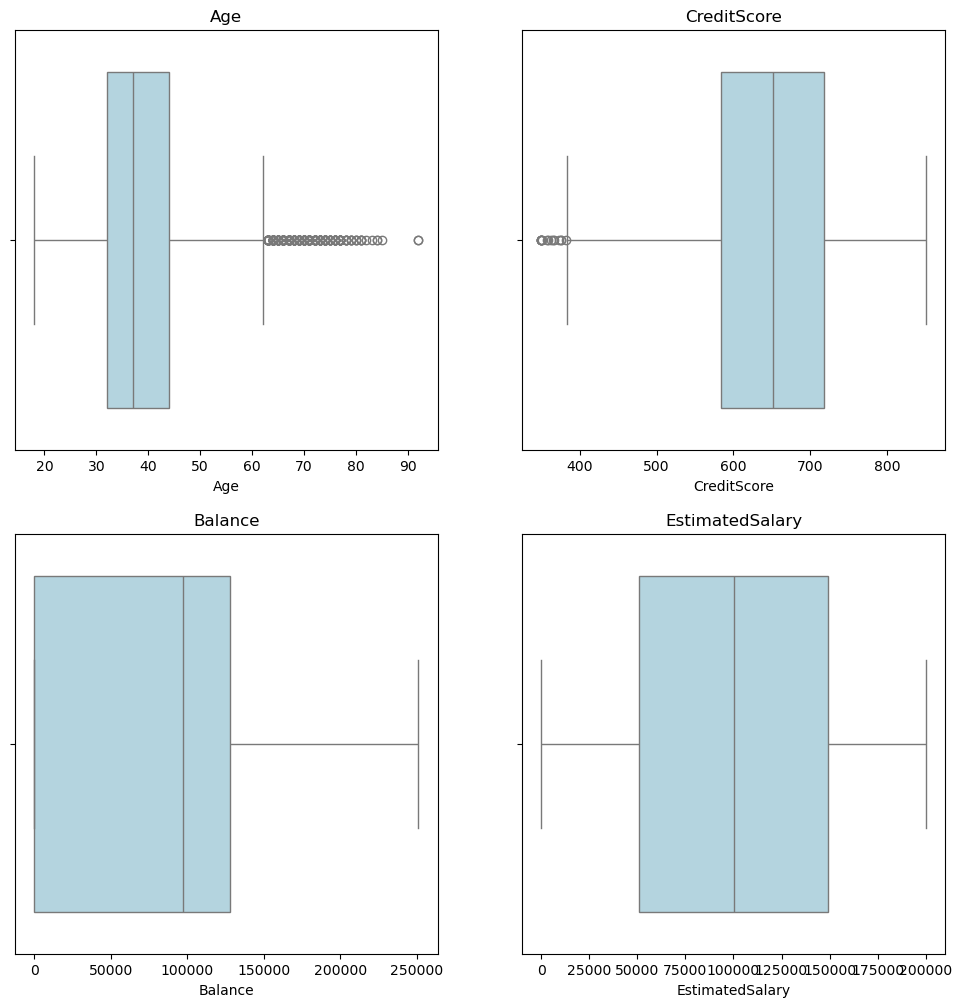

In [44]:
fig,axes= plt.subplots(2,2,figsize=(12,12))

for index,columns in enumerate(numerical_columns):
    axes= axes.flatten()
    sns.boxplot(x=columns,data=df,ax=axes[index],color='lightblue')
    axes[index].set_title(columns)


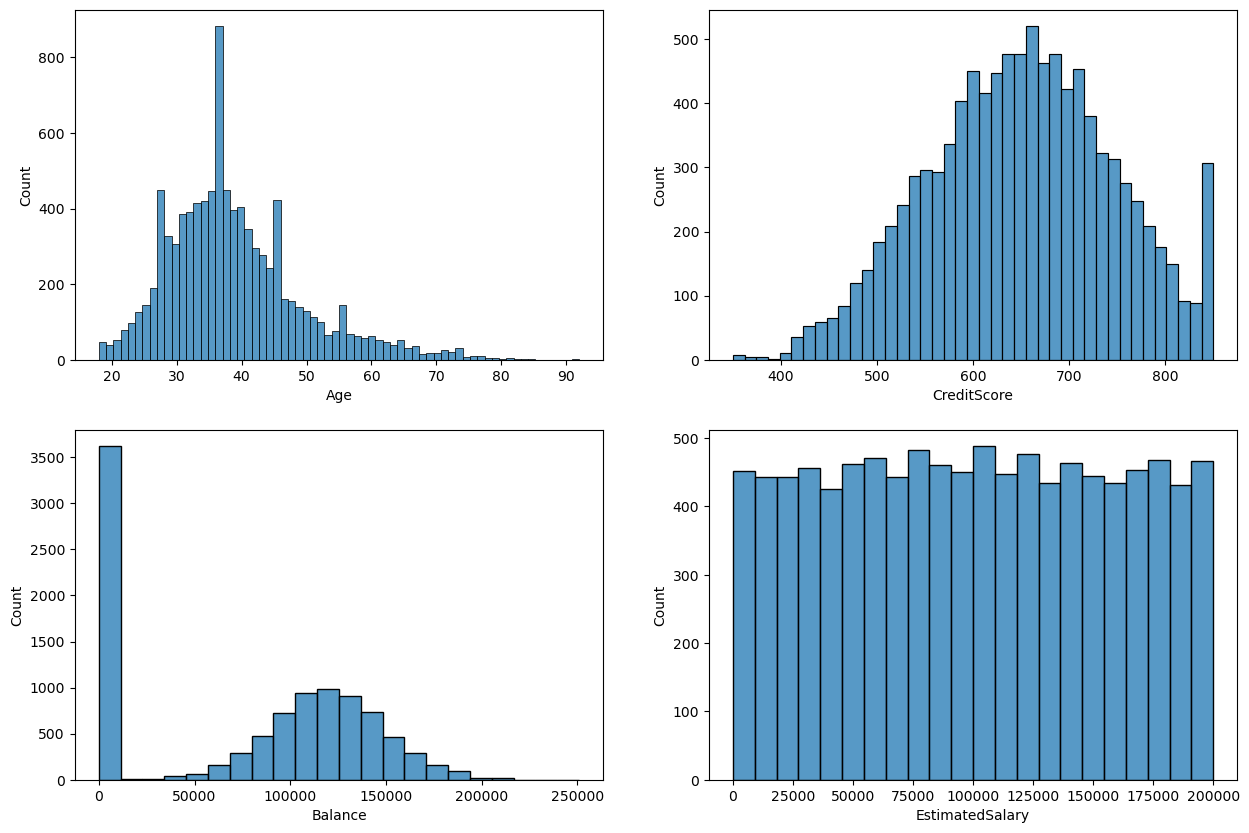

In [30]:
#Plot the numerical columns

fig,axes= plt.subplots(2,2,figsize=(15,10))

for index,column in enumerate(numerical_columns):
    axes= axes.flatten()
    sns.histplot(ax=axes[index],data=df,x=column)


<Axes: >

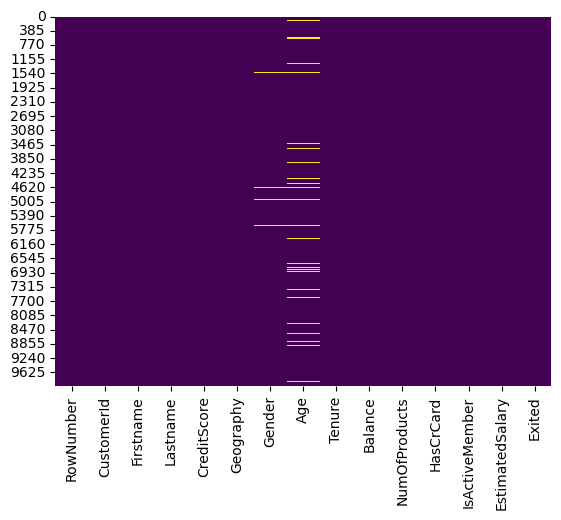

In [35]:
#Heatmap view of null values

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

In [36]:
df.columns

Index(['RowNumber', 'CustomerId', 'Firstname', 'Lastname', 'CreditScore',
       'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [37]:
df['Gender'].isnull().sum()

108

In [48]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [ ]:
pd.qcut(df['CreditScore'],q=5).value_counts().sort_index()

CreditScore
(349.999, 566.0]    2010
(566.0, 627.0]      2020
(627.0, 678.0]      2010
(678.0, 735.0]      1981
(735.0, 850.0]      1979
Name: count, dtype: int64

In [ ]:
def custom_binning(score):
    if score<566:
        return 'Poor'
    if score<627:
        return 'Fair'
    if score<678:
        return 'Good'
    if score<735:
        return 'Very Good'
    if score<=850:
        return 'Excellent'
    else:
         assert True," Credit score canot be greater tha 850"
    